# Chapter 14: Matrix Encoding

The previous chapter loaded a vector $\mathbf{b}$ into a quantum state; this chapter asks the harder
question: how do we encode a **matrix** $A$, and given an encoded $|x\rangle$, how do we carry out the
matrix-vector product $Ax$? (We do *not* solve $Ax=b$ here — that comes later.) The workhorse is the
**Linear Combination of Unitaries (LCU)** framework, built up step by step: an ancilla qubit that acts
as a weighted switch, controlled unitaries, and *uncomputation* to combine gate actions in
superposition.

The core recipe has four named stages — **PREP** (load coefficients $\sqrt{|c_k|/\alpha}$ into the
ancilla), **SELECT** (apply each unitary $P_k$ controlled on the ancilla), **UNPREP** ($P^\dagger$),
and **MEASURE** (post-select on ancilla $=|0\rangle$). Post-selection succeeds with probability
$p_{\text{success}}=\|Ax\|^2/\alpha^2 < 1$, a characteristic feature of quantum linear algebra. We
decompose $A$ into Pauli tensor products via `SparsePauliOp`, apply LCU to $4\times4$ FEM blocks, show
how to recover a scalar observable $f^\top A x$ at cost independent of matrix size, and close with the
practical bottlenecks (deep circuits, large $\alpha$) and the structured block-encoding families that
exploit sparsity and separability.

---

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions

## Setup for Google Colab; no impact when executed on local machine

In [1]:
import os, sys
 
if "google.colab" in sys.modules:
    if not os.path.isdir("/content/AppliedQC"):
        !git clone -q --depth 1 https://github.com/UW-ERSL/AppliedQC.git /content/AppliedQC
    exec(open("/content/AppliedQC/colab_setup.py").read())
 

In [2]:
# Setup and imports
import numpy as np
from scipy.sparse import diags
from copy import deepcopy
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import UnitaryGate, QFTGate
from qiskit.circuit.library import QFT, phase_estimation, HamiltonianGate
from qiskit.quantum_info import SparsePauliOp 
from qiskit.circuit.library import  StatePreparation,DiagonalGate, ZGate, XGate, RYGate, UCGate
from qiskit_aer.noise import NoiseModel, depolarizing_error
from Chapter04_EngineeringProblems_functions import (truss2x2,truss3x2,truss2x3,truss3x3,truss_10bar,
                                                         PlaneStressCantilever)
from Chapter08_QuantumGates_functions import  (simulate_statevector,  simulate_measurements)
from Chapter14_MatrixEncoding_functions import (LCU_Ax, LCU_fTAx, Pauli_Block_Encoding)

from IPython.display import display

# --- Figure export -------------------------------------------------
# Circuit drawings and plots are saved as PDF (vector) for the book.
import os
from contextlib import contextmanager
FIG_DIR = 'figs/Ch14-MatrixEncoding'

def save_circuit(qc, name=None, folder=FIG_DIR, show=True, fold=-1, **kwargs):
    """Draw a circuit in black and white; save it as PDF if `name` is given."""
    fig = qc.draw('mpl', style={'name': 'bw', 'creglinecolor': '#000000'},
                  fold=fold, **kwargs)
    if name:
        os.makedirs(folder, exist_ok=True)
        fig.savefig(f'{folder}/{name}.pdf', bbox_inches='tight')
    if show:
        display(fig)
    plt.close(fig)

def save_plot(fig, name, folder=FIG_DIR):
    """Save any matplotlib figure as PDF for the book."""
    os.makedirs(folder, exist_ok=True)
    fig.savefig(f'{folder}/{name}.pdf', bbox_inches='tight')
    return fig

@contextmanager
def capture_plot(name, folder=FIG_DIR):
    """Save a figure drawn by a helper that calls plt.show() itself.

    The inline backend closes a figure when plt.show() runs, so plt.gcf()
    afterwards returns a new, empty figure and writes a blank PDF."""
    _show = plt.show
    plt.show = lambda *a, **k: None
    try:
        yield
    finally:
        plt.show = _show
    fig = plt.gcf()
    os.makedirs(folder, exist_ok=True)
    fig.savefig(f'{folder}/{name}.pdf', bbox_inches='tight')
    display(fig)
    plt.close(fig)


## Weighted quantum gates  *(Book §14.2)*

Consider a matrix that is a linear combination of gates, e.g. $A = c_0 X + c_1 Z$. The key idea is to
apply unitary gates in a *weighted* sense using an ancilla qubit. This section builds that idea
step by step — ancilla, controlled operations, uncomputation — leading naturally into the LCU
framework.

### The Pauli gate matrices  *(Book §14.1, Eq. 14.1)*

We first define the Pauli operators as explicit unitaries so they can be used as controlled gates:
$$X=\begin{bmatrix}0&1\\1&0\end{bmatrix},\;\; Y=\begin{bmatrix}0&-i\\i&0\end{bmatrix},\;\; Z=\begin{bmatrix}1&0\\0&-1\end{bmatrix}.$$
Encoding a matrix that *is* a standard gate is trivial — it is just that gate.

In [3]:

X_matrix = np.array([[0, 1], [1,  0]], dtype=complex)
Y_matrix = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z_matrix = np.array([[1, 0], [0, -1]], dtype=complex)


X_gate = UnitaryGate(X_matrix, label='X')
Y_gate = UnitaryGate(Y_matrix, label='Y')
Z_gate = UnitaryGate(Z_matrix, label='Z')


### A single gate  *(Book §14.1)*

The simplest case: $A$ is a single Pauli. Encoding it is nothing more than appending that gate to the
circuit — here $Z$ on one qubit.

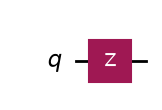

In [4]:
qc = QuantumCircuit(1)
qc.append(Z_gate, [0])
display(qc.draw('mpl'))

### Two gates, equal probability  *(Book §14.2, Example 14.1)*

To apply $X$ or $Z$ each with probability $\tfrac12$, introduce an **ancilla** q0 as a switch. Put it
in uniform superposition with $H$, then apply $Z$ on the system when q0$=|0\rangle$ and $X$ when
q0$=|1\rangle$. Measuring the ancilla reveals which gate was applied — the ancilla acts as a classical
switch.

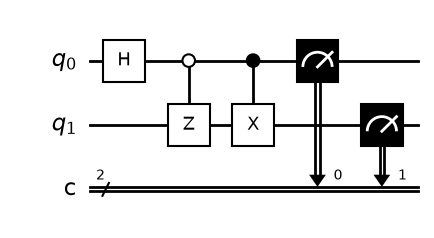

Measurement Counts: {'11': 500, '00': 500}


In [5]:
qc = QuantumCircuit(2, 2)
qc.h(0)    
qc.append(Z_gate.control(1, ctrl_state='0'), [0, 1])
qc.append(X_gate.control(1, ctrl_state='1'), [0, 1])
qc.measure([0, 1], [0, 1])
save_circuit(qc, 'SelectingBetween2Gates')
counts = simulate_measurements(qc, shots=1000)
print("Measurement Counts:", counts)


### Two gates, unequal probability  *(Book §14.2, Example 14.2)*

To apply $Z$ with probability $\tfrac23$ and $X$ with $\tfrac13$, the only change is the ancilla
preparation: replace $H$ with $R_Y(\theta)$, where $\theta = 2\arctan\!\sqrt{1/2}$ sets the amplitudes
so $P(q_0{=}0)=\tfrac23$. $R_Y$ is the natural generalization of $H$: it encodes arbitrary probabilities
as amplitudes. A typical run gives roughly $\{00\!:\!680,\, 11\!:\!320\}$.

Resulting Statevector:


<IPython.core.display.Latex object>

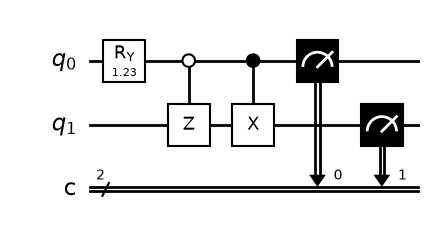

Measurement Counts: {'11': 336, '00': 664}


In [6]:
qc = QuantumCircuit(2, 2)
c = np.array([2/3, 1/3])
theta = 2 * np.arctan(np.sqrt(c[1] / c[0]))
qc.ry(theta, 0)  
qc.append(Z_gate.control(1, ctrl_state='0'), [0, 1])
qc.append(X_gate.control(1, ctrl_state='1'), [0, 1])
state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
qc.measure([0, 1], [0, 1])
save_circuit(qc, 'SelectingBetween2GatesRy')
counts = simulate_measurements(qc, shots=1000)
print("Measurement Counts:", counts)


### Both gates together: uncomputation  *(Book §14.2, Example 14.3)*

Now we want *both* gates to act and combine in superposition, i.e. apply $A=\tfrac23 Z + \tfrac13 X$.
PREP and SELECT are unchanged; the new ingredient is **uncomputation** — applying $R_Y(-\theta)$ to
bring the ancilla back toward $|0\rangle$. The two cells below contrast the approach:
- The first uses $H\cdots H$ (with $Y$ and $X$) to sandwich the controlled gates.
- The second uses the $R_Y(\theta)\cdots R_Y(-\theta)$ uncomputation that is the true LCU prototype.

After uncomputation, post-selecting on ancilla $=|0\rangle$ leaves the system in the state
$\propto A|x\rangle$, here with success probability $P=\tfrac59\approx56\%$; ancilla $=|1\rangle$ is a
failure that must be re-run.

Resulting Statevector:


<IPython.core.display.Latex object>

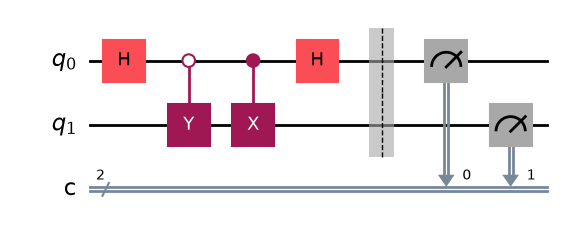

In [7]:
qc = QuantumCircuit(2, 2)
qc.h( 0)                      
qc.append(Y_gate.control(1, ctrl_state='0'), [0, 1])
qc.append(X_gate.control(1, ctrl_state='1'), [0, 1])
qc.h( 0)        
state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
qc.barrier()
qc.measure([0, 1], [0, 1])
display(qc.draw('mpl'))

### Uncomputation via $R_Y(\theta)\cdots R_Y(-\theta)$  *(Book §14.2, Example 14.3)*

This is the true LCU prototype: PREP with $R_Y(\theta)$, SELECT the controlled $Z$ and $X$, then UNPREP
with $R_Y(-\theta)$. Collecting the ancilla-$|0\rangle$ terms leaves the system in
$\tfrac23|0\rangle+\tfrac13|1\rangle \propto A|x\rangle$. Keeping only the ancilla-$0$ shots
(here $\{00,10\}$) recovers amplitudes $\approx(0.90,0.43)\propto(\tfrac23,\tfrac13)$, up to
normalization.

Resulting Statevector:


<IPython.core.display.Latex object>

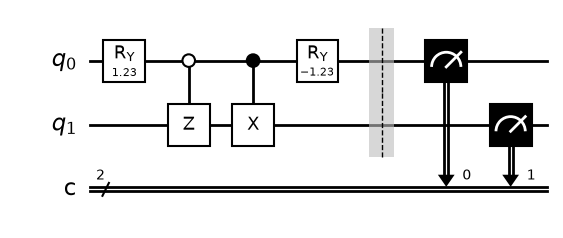

Counts: {'00': 436, '10': 119, '11': 238, '01': 207}


In [8]:
qc = QuantumCircuit(2, 2)
c = np.array([2/3, 1/3])
theta = 2 * np.arctan(np.sqrt(c[1] / c[0]))
qc.ry(theta, 0)                      
qc.append(Z_gate.control(1, ctrl_state='0'), [0, 1])
qc.append(X_gate.control(1, ctrl_state='1'), [0, 1])
qc.ry(-theta, 0)        
state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
qc.barrier()
qc.measure([0, 1], [0, 1])
save_circuit(qc, 'Uncomputation')

counts = simulate_measurements(qc, shots=1000)
print("Counts:", counts)


## LCU Example 1  *(Book §14.3, Example 14.4)*

We now compute $Ax$ for $A=\begin{bmatrix}2/3&1/3\\1/3&-2/3\end{bmatrix}=\tfrac23 Z+\tfrac13 X$ and
$x=|0\rangle$. This is exactly the weighted-gate circuit of the previous example — the central message
of LCU is that *applying a weighted combination of unitaries to $|x\rangle$, with uncomputation, is the
same as computing $A|x\rangle$*. The four stages have standard names: PREP, SELECT, UNPREP, MEASURE.

### Step 1 — PREP: prepare the ancilla coefficients

$R_Y(\theta)$ with $\theta = 2\arctan\!\sqrt{c_1/c_0}$ loads the coefficient magnitudes into the
ancilla amplitudes $(\sqrt{2/3},\sqrt{1/3})$.

Classical y: [0.66666667 0.33333333]
Resulting Statevector:


<IPython.core.display.Latex object>

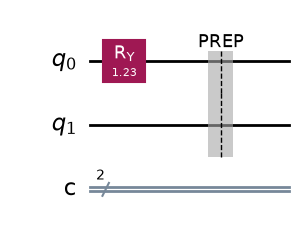

In [9]:
# A = [2/3 1/3; 1/3 -2/3]
# A = 2/3*Z + 1/3*X
# x = [1,0]

A = np.array([[2/3, 1/3], [1/3, 2/3]])

x= np.array([1,0])
y_classical = A @ x
print("Classical y:", y_classical)
qc = QuantumCircuit(2, 2)
c = np.array([2/3, 1/3])
theta = 2 * np.arctan(np.sqrt(c[1]/c[0]))
qc.ry(theta, 0)  
qc.barrier(label = "PREP")
state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
display(qc.draw('mpl'))

### Step 2 — SELECT: apply the controlled unitaries  *(Book §14.3)*

The SELECT stage applies each unitary controlled on the ancilla: $Z$ when q0$=|0\rangle$ and $X$ when
q0$=|1\rangle$. After SELECT the two-qubit state is $\sqrt{2/3}\,|00\rangle+\sqrt{1/3}\,|11\rangle$.

Resulting Statevector:


<IPython.core.display.Latex object>

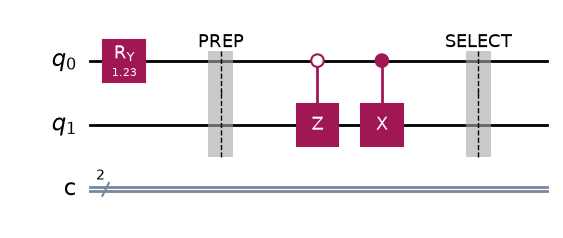

In [10]:
qc.append(Z_gate.control(1, ctrl_state='0'), [0, 1])
qc.append(X_gate.control(1, ctrl_state='1'), [0, 1])
qc.barrier(label = "SELECT")
state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
display(qc.draw('mpl'))

### Step 3 — UNPREP: uncompute the ancilla  *(Book §14.3)*

UNPREP applies $P^\dagger = R_Y(-\theta)$ to the ancilla. This is the crucial step that combines the
two gate actions in the system register while pushing the desired result into the ancilla-$|0\rangle$
branch.

Resulting Statevector:


<IPython.core.display.Latex object>

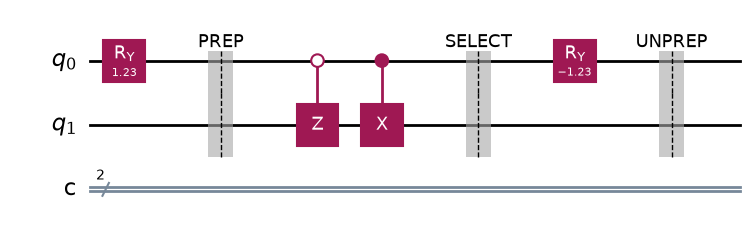

In [11]:
qc.ry(-theta, 0)
qc.barrier(label = "UNPREP")
state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
display(qc.draw('mpl'))

### Step 4 — MEASURE: post-select  *(Book §14.3)*

Finally we measure. Retaining only the shots where the **ancilla reads 0** gives the system state
$\propto A|x\rangle = (\tfrac23,\tfrac13)^\top$. The success probability is
$p_{\text{success}}=\|Ax\|^2/\alpha^2$; the failed shots (ancilla $=1$) are discarded.

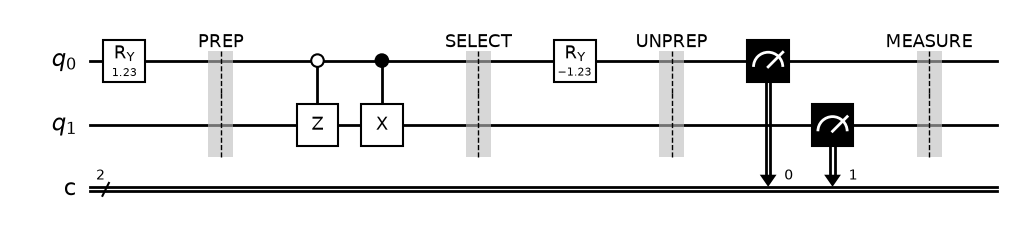

Measurement Counts: {'11': 2377, '00': 4383, '01': 2179, '10': 1061}


In [12]:
qc.measure(0, 0)   # measure ancilla q0 -> classical bit 0
qc.measure(1, 1)   # measure system  q1 -> classical bit 1
qc.barrier(label = "MEASURE")
save_circuit(qc, 'LCUTerminology')
nShots = 10000
counts = simulate_measurements(qc, shots=nShots)
print("Measurement Counts:", counts)


### $Ax$ with coefficients not summing to 1  *(Book §14.3, Example 14.5)*

For $A=\begin{bmatrix}2&1\\1&-2\end{bmatrix}=2Z+X$ the coefficients $(2,1)$ do not sum to 1. The fix:
set the subnormalization $\alpha=\sum_k|c_k|=3$, load ancilla amplitudes $\sqrt{|c_k|/\alpha}$, run the
same PREP-SELECT-UNPREP-MEASURE circuit, and **multiply the recovered result by $\alpha$** to get
$Ax=(2,1)^\top$.

Full statevector: [ 0.6667+0.j -0.4714+0.j  0.3333+0.j  0.4714+0.j]

LCU result:    [2. 1.]
Classical Ax:  [2. 1.]
Match:         True

Success probability: 0.5556  (= ||Ax||^2 / alpha^2 = 5.0000 / 9.0000)



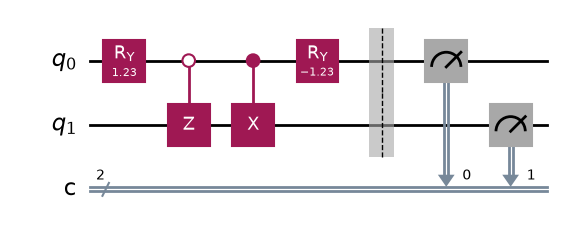

In [13]:

# A = [2 1; 1 -2] = 2*Z + 1*X
# 1. Define A and x
A = np.array([[2, 1], [1, -2]])
c0, c1 = 2, 1
alpha   = c0 + c1            # = 3


x        = np.array([1, 0], dtype=complex)   # |0>
expected = A @ x



# 3. Build circuit
# q0 = ancilla, q1 = system
qc = QuantumCircuit(2, 2)

# PREP: 
theta = 2 * np.arctan(np.sqrt(c1 / c0))
qc.ry(theta, 0)

# System qubit: x = |0>, no gate needed

qc.append(Z_gate.control(1, ctrl_state='0'), [0, 1])
qc.append(X_gate.control(1, ctrl_state='1'), [0, 1])

# Inverse rotation on ancilla
qc.ry(-theta, 0)

# 4. Simulate statevector
state = Statevector.from_instruction(qc)
print("Full statevector:", np.round(state.data, 4))
print()
qc.barrier()
qc.measure(0, 0)   # measure ancilla q0 -> classical bit 0
qc.measure(1, 1)   # measure system  q1 -> classical bit 1
# 5. Post-select on ancilla q0 = 0 (even indices: 0, 2)
# and rescale by alpha
result = state.data[[0, 2]] * alpha
print("="*40)
print("LCU result:   ", np.round(np.real_if_close(result),   4))
print("Classical Ax: ", np.round(np.real_if_close(expected), 4))
print("Match:        ", np.allclose(result, expected))
print("="*40)
print()

# 6. Success probability
prob = np.linalg.norm(state.data[[0, 2]])**2
print(f"Success probability: {prob:.4f}  (= ||Ax||^2 / alpha^2 = {np.linalg.norm(expected)**2:.4f} / {alpha**2:.4f})")

# 7. Draw circuit
print()
qc.draw('mpl')

### $Ax$ with a negative coefficient  *(Book §14.3, Example 14.6)*

For $A=2Z-X$ with $x=|-\rangle$, the sign of $c_1=-1$ cannot be absorbed into $\alpha$ or the ancilla
(amplitudes must be real and non-negative). Instead the phase $e^{i\pi}=-1$ is folded into the
controlled gate, making it a controlled-$(-X)$. In general, for $c_k=|c_k|e^{i\phi_k}$, encode the
magnitude in the ancilla and absorb the phase into the corresponding controlled unitary. Here
$\alpha=3$ and $p_{\text{success}}=\tfrac59$.

Full statevector: [ 0.7071+0.j  0.    +0.j  0.2357+0.j -0.6667-0.j]

LCU result:    [2.1213 0.7071]
Classical Ax:  [2.1213 0.7071]
Match:         True

Success probability: 0.5556  (= ||Ax||^2 / alpha^2 = 5.0000 / 9.0000)



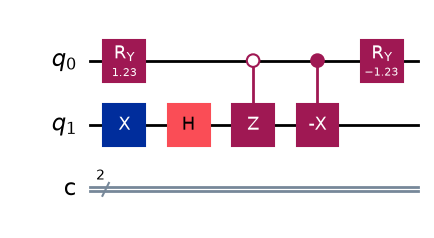

In [14]:
# -------------------------------------------------------
# LCU Example 3: A = 2Z - X, x = |->, alpha = 3
# -------------------------------------------------------

# 1. Define A and x
A = np.array([[2, -1], [-1, -2]])
x        = np.array([1, -1], dtype=complex) / np.sqrt(2)   # |->
c0, c1 = 2.0, -1.0
alpha   = np.abs(c0) + np.abs(c1)   # = 3
expected = A @ x

# 2. PREP angle
# Uses |c0|, |c1| -- sign is handled separately via global_phase

# 3. Phase of each coefficient
phase0 = np.angle(c0)   # 0   (c0 > 0)
phase1 = np.angle(c1)   # pi  (c1 < 0)


# X with global phase of -1 (i.e., phase = pi)
X_matrix = np.array([[0, 1], [1, 0]], dtype=complex)
X_phased = UnitaryGate(-1 * X_matrix, label='-X')   # multiply matrix by -1

# 4. Build circuit
# q0 = ancilla, q1 = system
qc = QuantumCircuit(2, 2)

# PREP: same angle as Example 2 since |c0|, |c1| unchanged
theta = 2 * np.arctan(np.sqrt(np.abs(c1) / np.abs(c0)))
qc.ry(theta, 0)

# System qubit: x = |->
qc.x(1)
qc.h(1)

# SELECT: controlled unitaries
qc.append(Z_gate.control(1, ctrl_state='0'), [0, 1])
qc.append(X_phased.control(1, ctrl_state='1'), [0, 1])


# Inverse rotation on ancilla
qc.ry(-theta, 0)

# 5. Simulate statevector
state = Statevector.from_instruction(qc)
print("Full statevector:", np.round(state.data, 4))
print()

# 6. Post-select on ancilla q0 = 0 (even indices: 0, 2)
# and rescale by alpha
result = state.data[[0, 2]] * alpha
print("="*40)
print("LCU result:   ", np.round(np.real_if_close(result),   4))
print("Classical Ax: ", np.round(np.real_if_close(expected), 4))
print("Match:        ", np.allclose(result, expected))
print("="*40)
print()

# 7. Success probability
prob = np.linalg.norm(state.data[[0, 2]])**2
print(f"Success probability: {prob:.4f}  (= ||Ax||^2 / alpha^2 = {np.linalg.norm(expected)**2:.4f} / {alpha**2:.4f})")

# 8. Draw circuit
print()
qc.draw('mpl')

### Tensor products of Pauli gates  *(Book §14.4, Examples 14.9-14.11)*

To encode $4\times4$ matrices we need $4\times4$ unitaries, built as tensor products $\sigma_i\otimes\sigma_j$.
The 16 such products form a basis for all $4\times4$ Hermitian matrices. Their circuits are simple: the
gate for $X\otimes Y$ is just $X$ on the high qubit and $Y$ on the low qubit, as shown here.

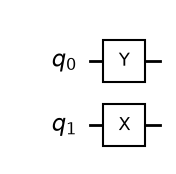

In [15]:
qc = QuantumCircuit(2)

qc.x(1)
qc.y(0)
save_circuit(qc, 'tensorProductCircuit')


### $Ax$ for a $4\times4$ matrix  *(Book §14.4, Example 14.12)*

We now run LCU on $A=\tfrac34(Z\otimes I)+\tfrac14(I\otimes X)$ with $x=|00\rangle$. Since
$c_0+c_1=1$, no rescaling is needed; one ancilla suffices (two coefficient terms) plus two system
qubits. PREP loads $(\tfrac{\sqrt3}{2},\tfrac12)$, SELECT applies $Z\otimes I$ or $I\otimes X$, and
post-selecting on ancilla $=|0\rangle$ recovers $(\tfrac34,\tfrac14,0,0)^\top$ with
$p_{\text{success}}=\tfrac58$.

A =
[[ 0.75  0.25  0.    0.  ]
 [ 0.25  0.75  0.    0.  ]
 [ 0.    0.   -0.75  0.25]
 [ 0.    0.    0.25 -0.75]]

Classical x = [1. 0. 0. 0.]

Classical A*x = [0.75 0.25 0.   0.  ]

theta = 1.0472 rad


<IPython.core.display.Latex object>


Quantum result (post-selected on ancilla=|0>, rescaled by alpha):
[0.75 0.25 0.   0.  ]

Classical A*x:
[0.75 0.25 0.   0.  ]

Results match: True

Success probability = 0.6250  (62.5%)


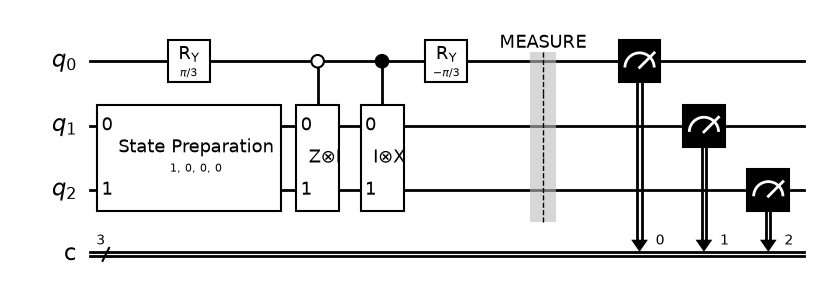

In [16]:
# ── Pauli matrices ────────────────────────────────────────────────────────
I = np.eye(2, dtype=complex)
Z = np.array([[1,  0], [0, -1]], dtype=complex)
X = np.array([[0,  1], [1,  0]], dtype=complex)

# ── Matrix A = 3/4 (Z⊗I) + 1/4 (I⊗X) ────────────────────────────────────
c0, c1 = 3/4, 1/4
alpha   = c0 + c1                        # = 1.0

A = c0 * np.kron(Z, I) + c1 * np.kron(I, X)
print("A =")
print(np.real_if_close(A))

# ── Classical result  x = |00> = (1,0,0,0) ───────────────────────────────
x = np.array([1, 0, 0, 0], dtype=complex)
x = x/np.linalg.norm(x)  # normalize to unit length
print("\nClassical x =", np.real_if_close(x))
Ax_classical = A @ x
print("\nClassical A*x =", np.real_if_close(Ax_classical))

# ── Ancilla preparation angle ─────────────────────────────────────────────
theta = 2 * np.arctan(np.sqrt(c1 / c0)) 
print(f"\ntheta = {theta:.4f} rad")

# ── Custom 2-qubit gates with explicit labels ─────────────────────────────
ZI_gate = UnitaryGate(np.kron(Z, I), label='Z⊗I')
IX_gate = UnitaryGate(np.kron(I, X), label='I⊗X')

# ── Quantum circuit: q0 = ancilla, q1,q2 = system qubits ─────────────────
qc = QuantumCircuit(3, 3)

# Step 1: prepare ancilla — encodes weights sqrt(3/4)|0> + sqrt(1/4)|1>
qc.ry(theta, 0)

qc.append(StatePreparation(x), [1, 2])  # prepare system state |00>

# Step 2: controlled-(Z⊗I) when ancilla q0=|0>
qc.append(ZI_gate.control(1, ctrl_state='0'), [0, 1, 2])

# Step 3: controlled-(I⊗X) when ancilla q0=|1>
qc.append(IX_gate.control(1, ctrl_state='1'), [0, 1, 2])

# Step 4: uncompute ancilla
qc.ry(-theta, 0)

sv = Statevector.from_instruction(qc)
display(sv.draw('latex'))
        
# Step 5: measure all qubits
qc.barrier(label="MEASURE")
qc.measure([0, 1, 2], [0, 1, 2])

# Post-select on ancilla q0=0: indices {0, 2, 4, 6} of the statevector
result = np.real_if_close(sv.data[[0, 2, 4, 6]]) * alpha
print("\nQuantum result (post-selected on ancilla=|0>, rescaled by alpha):")
print(np.round(result, 6))

print("\nClassical A*x:")
print(np.real_if_close(Ax_classical))

print("\nResults match:", np.allclose(result, Ax_classical))

# ── Success probability ───────────────────────────────────────────────────
P_success = np.linalg.norm(A @ x)**2 / alpha**2
print(f"\nSuccess probability = {P_success:.4f}  ({P_success*100:.1f}%)")

# ── Save circuit diagram ──────────────────────────────────────────────────
save_circuit(qc, 'Ax4x4')


## Pauli expansion  *(Book §14.5, Example 14.17)*

To apply LCU to a *general* matrix we need a systematic decomposition into unitaries. Any $2^m\times2^m$
matrix has a unique Pauli expansion $A=\sum_k c_k P_k$ with $c_k=\tfrac1{2^m}\mathrm{Tr}(A P_k)$, where
each $P_k$ is a tensor product of $\{I,X,Y,Z\}$. Qiskit's `SparsePauliOp.from_operator` computes it
efficiently. For the matrix here the result is $A = I\otimes I + 0.25\,X\otimes X - 0.25\,Y\otimes Y$
(note Qiskit's little-endian string ordering, qubit 0 on the right).

In [17]:
A = np.array([
    [1, 0, 0, -0.5],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [-0.5, 0, 0, 1]
])
pauliSplit = SparsePauliOp.from_operator(A)
print(pauliSplit.paulis)
print(pauliSplit.coeffs)



['II', 'XX', 'YY']
[ 1.  +0.j -0.25+0.j  0.25-0.j]


### Reconstruction check  *(Book §14.5)*

As a sanity check, we rebuild $A$ from its Pauli terms by summing $c_k P_k$ over the decomposition and
confirm it matches the original matrix — verifying the expansion is exact.

In [18]:
B = np.zeros_like(A,dtype=complex)
for i, (pauli, coeff) in enumerate(zip(pauliSplit.paulis, pauliSplit.coeffs)):
    print(f"\nPauli term {i}:")
    print(f"Coefficient: {coeff}")
    print(f"Pauli string: {pauli.to_label()}")
    print(pauli.to_matrix())
    B += coeff * pauli.to_matrix()

print("\nReconstructed A from Pauli decomposition:")
print(np.real_if_close(B))


Pauli term 0:
Coefficient: (1+0j)
Pauli string: II
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]]

Pauli term 1:
Coefficient: (-0.25+0j)
Pauli string: XX
[[0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]]

Pauli term 2:
Coefficient: (0.25-0j)
Pauli string: YY
[[ 0.+0.j  0.+0.j  0.+0.j -1.+0.j]
 [ 0.+0.j  0.+0.j  1.-0.j  0.+0.j]
 [ 0.+0.j  1.-0.j  0.+0.j  0.+0.j]
 [-1.+0.j  0.+0.j  0.+0.j  0.+0.j]]

Reconstructed A from Pauli decomposition:
[[ 1.   0.   0.  -0.5]
 [ 0.   1.   0.   0. ]
 [ 0.   0.   1.   0. ]
 [-0.5  0.   0.   1. ]]


## Performing $Ax$ with `LCU_Ax`  *(Book §14.6, Example 14.18)*

The full PREP/SELECT/UNPREP pipeline (Eqs. 14.8-14.13) is packaged in `LCU_Ax`, which takes $A$ and
$x$ and returns the circuit plus metadata ($\alpha$, ancilla/system qubit counts). Since the ancilla
occupies the least-significant qubits, the system amplitudes are extracted by striding the statevector
by $2^{n_{\text{anc}}}$ and rescaling by $\alpha$. Here the recovered $Ax=(0.6,0.8,0,0.3)$ matches the
classical result, and $p_{\text{success}}\approx0.484 = \|Ax\|^2/\alpha^2$ as predicted.

{'alpha': 1.5, 'num_system': 2, 'num_ancilla': 2, 'coeffs': array([ 1.  +0.j, -0.25+0.j,  0.25-0.j]), 'pauli_split': SparsePauliOp(['II', 'XX', 'YY'],
              coeffs=[ 1.  +0.j, -0.25+0.j,  0.25-0.j]), 'ancilla_zero_stride': 4}
Expected output: [ 0.6  0.8  0.  -0.3]
Quantum output: [ 0.6  0.8 -0.  -0.3]
Success probability: 0.4844


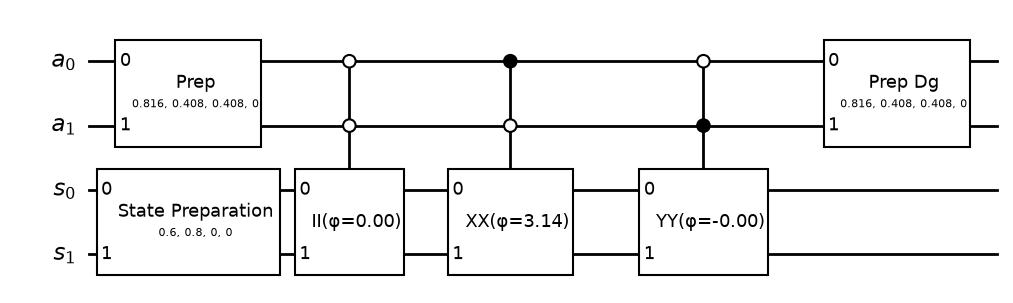

In [19]:
A = np.array([
    [1, 0, 0, -0.5],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [-0.5, 0, 0, 1]
], dtype=float)

x = np.array([0.6, 0.8, 0, 0], dtype=complex)

expected_output = A @ x

# Create circuit
qc, metadata = LCU_Ax(A, x)
print(metadata)

# Get the exact statevector
final_state = Statevector(qc)
num_system = metadata['num_system']
num_ancilla = metadata['num_ancilla']
alpha = metadata['alpha']
stride = metadata['ancilla_zero_stride']

res_vector   = final_state.data[::2**num_ancilla] * alpha
success_prob = np.linalg.norm(final_state.data[::2**num_ancilla])**2

print("Expected output:", np.round(np.real_if_close(expected_output), 4))
print("Quantum output:", np.round(np.real_if_close(res_vector), 4))
print("Success probability:", np.round(success_prob, 4))
save_circuit(qc, 'LCU4x4')


## LCU on FEM truss stiffness matrices  *(Book §14.8)*

We now apply LCU to a realistic finite-element stiffness matrix from the $3\times3$ truss of Chapter 4.
The full $K$ is $18\times18$; after removing fixed DOFs it is $14\times14$. Since $K$ is not a power of
two, we extract an $8\times8$ sub-block and compute its Pauli expansion. This dense FEM block yields
**24** Pauli terms — needing $\lceil\log_2 24\rceil=5$ ancilla and 3 system qubits — and a very large
normalization $\alpha$ (physical units inflate it), illustrating the practical cost of unstructured
matrices.

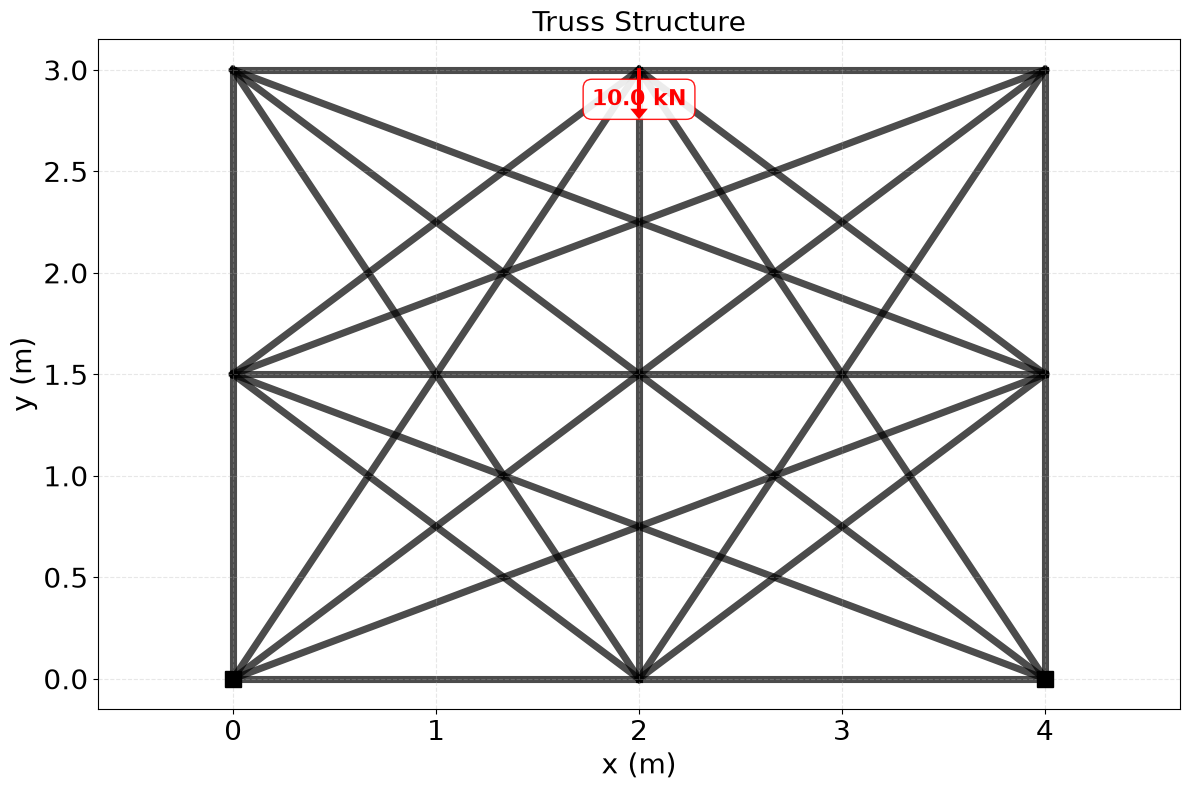

Size of K_full: (18, 18)
Size of K: (14, 14)
Size of sub-matrix A: (8, 8)
Number of Pauli terms: 24
Ancilla qubits needed: 5
System qubits needed: 3
Total qubits: 8
Normalization α: 4.2030e+08


In [20]:
fem_model= truss3x3()
fem_model.plot_truss()
K_full = fem_model.assemble_stiffness()
print("Size of K_full:", K_full.shape)
all_dofs = set(range(fem_model.n_dofs))
free_dofs = list(all_dofs - set(fem_model.fixed_dofs))
K = K_full[np.ix_(free_dofs, free_dofs)]
f = fem_model.loads[free_dofs]
print("Size of K:", K.shape)
N = 8
A = K[:N, :N]  # Just take a N x N block for testing
print("Size of sub-matrix A:", A.shape)
pauliSplit = SparsePauliOp.from_operator(A)
print("Number of Pauli terms:",pauliSplit.coeffs.shape[0])

# Resource requirements
num_ancilla = int(np.ceil(np.log2(pauliSplit.coeffs.shape[0])))  # One ancilla per Pauli term
num_system = int(np.ceil(np.log2(N)))
print(f"Ancilla qubits needed: {num_ancilla}")
print(f"System qubits needed: {num_system}")
print(f"Total qubits: {num_ancilla + num_system}")

# Normalization constant
alpha = np.sum(np.abs(pauliSplit.coeffs))
print(f"Normalization α: {alpha:.4e}")

## FEM circuit depth analysis  *(Book §14.8)*

The many Pauli terms make the circuit deep. Decomposing the LCU circuit for this $8\times8$ block to
the native gate set (`mode='statevector'` returns the exact state rather than a sample) reports a
depth of **347** and **892** total gates — already challenging for NISQ hardware, and this is before
any iteration. This motivates the structured block-encoding families (§14.9) that exploit sparsity and
separability to keep depth $O(\mathrm{poly}(m))$.

In [21]:
# Create a simple test vector
x = np.zeros(8)
x[0] = 1.0  # Unit displacement at first DOF

# Create LCU circuit
qc, metadata = LCU_Ax(A, x, mode='statevector')

# Analyze circuit
print(f"Circuit depth: {qc.depth()}")
print(f"Number of qubits: {qc.num_qubits}")

# Decompose to basis gates
# Transpile to a fixed native basis at a pinned optimization level.
# decompose(reps=n) is NOT a stable cost metric -- the count swings by an
# order of magnitude with n and with the Qiskit release.  Note also that
# the transpiler's default optimization_level moved from 1 to 2 in Qiskit 2.x.
qc_native = transpile(qc, basis_gates=['u', 'cx'], optimization_level=1)
print(f"\nAfter transpilation to the native basis {{u, cx}}:")
print(f"Transpiled depth: {qc_native.depth()}")
print(f"Total gates: {sum(qc_native.count_ops().values())}")
print(f"Two-qubit (CX) gates: {qc_native.count_ops()['cx']}")

Circuit depth: 26
Number of qubits: 8

After transpilation to the native basis {u, cx}:
Transpiled depth: 4280
Total gates: 5642
Two-qubit (CX) gates: 2476


## Computing the observable $f^\top A x$  *(Book §14.7, Example 14.19)*

Full state readout costs $O(2^m)$ measurements, offsetting the quantum advantage. But often we only
need a *scalar* observable such as $f^\top A x$ (a proxy for $f^\top A^{-1} b$ — compliance, energy, a
loss). The trick: after post-selecting on ancilla $=|0\rangle$, apply $U_f^\dagger$ (where
$U_f|0\rangle=|f\rangle$) and estimate the probability $p_0$ of measuring all-zeros, since
$p_0=|f^\top Ax|^2/\|Ax\|^2$. Then $|f^\top Ax| = \sqrt{p_0}\cdot\alpha\sqrt{p_{\text{success}}}$.
`LCU_fTAx` implements this; the cost is $O(1/\varepsilon^2)$ shots, **independent of matrix size** —
but only the magnitude is recovered.

Expected output (f^T A x): 0.4754
Quantum output (f^T A x): 0.4762


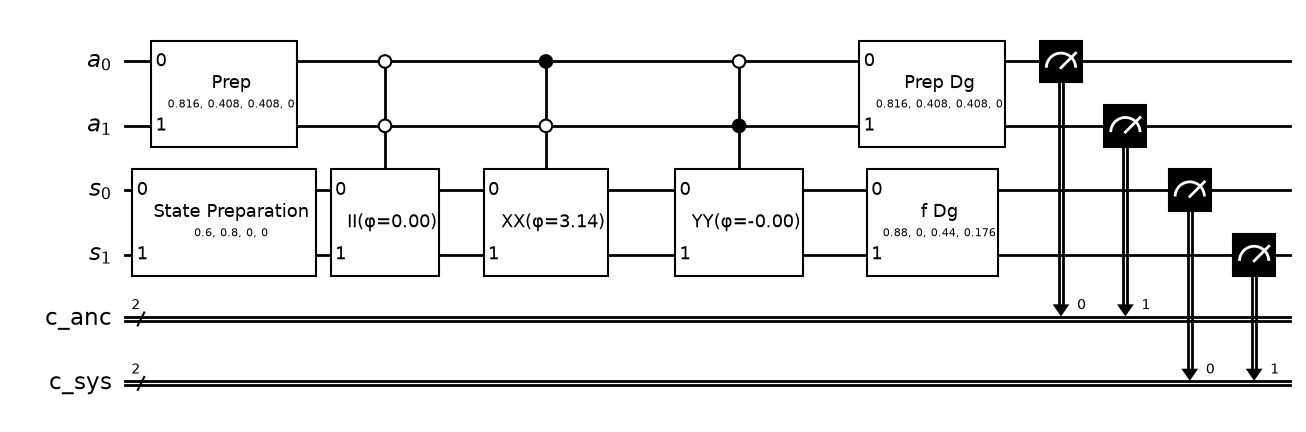

In [22]:
A = np.array([
    [1, 0, 0, -0.5],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [-0.5, 0, 0, 1]
], dtype=float)

x = np.array([0.6, 0.8, 0, 0], dtype=complex)

f = np.array([1, 0, 0.5, 0.2], dtype=complex)
f = f / np.linalg.norm(f)  # Normalize f to unit length

expected_output = f @ A @ x
print("Expected output (f^T A x):", np.round(np.real_if_close(expected_output), 4))

[result, qc, metadata] = LCU_fTAx(f, A, x, shots=10000)
print("Quantum output (f^T A x):", np.round(np.real_if_close(result), 4))
save_circuit(qc, 'ObservableCircuit')


## Observable $f^\top A x$ under noise  *(Book §14.7, Example 14.20)*

Finally we study how a low success probability and hardware noise affect the observable estimate. With
$\alpha=1.5$ and $p_{\text{success}}\approx0.484$, only a fraction of shots pass post-selection, and of
those only $p_0$ yield the all-zeros string — so tight accuracy demands many shots (e.g. $\sim$8,500
for $\varepsilon=0.01$). Comparing the noiseless and noisy runs shows the combined statistical and
device-noise penalty on the recovered $|f^\top Ax|$.

In [23]:
A = np.array([
    [1, 0, 0, -0.5],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [-0.5, 0, 0, 1]
], dtype=float)

x = np.array([0.6, 0.8, 0, 0], dtype=complex)

f = np.array([1, 0, 0.5, 0.2], dtype=complex)
f = f / np.linalg.norm(f)  # Normalize f to unit length

expected_output = f @ A @ x
print("Classical output        :", np.round(np.real_if_close(expected_output), 4))

shots = 10000
[result_ideal, qc, metadata_ideal] = LCU_fTAx(f, A, x, shots=shots)
print("Quantum output (No noise):", np.round(np.real_if_close(result_ideal), 4))
print("Success_prob (No noise):", metadata_ideal['success_prob'])

noise_model = NoiseModel()
error_1q = depolarizing_error(0.001, 1) # 1-qubit gates
error_2q = depolarizing_error( 0.01, 2) # 2-qubit gates

single_qubit_gates = ['u1', 'u2', 'u3', 'u',   # generic unitaries
                      'h', 'x', 'y', 'z',        # Pauli + Hadamard
                      's', 'sdg', 't', 'tdg',    # phase gates
                      'rx', 'ry', 'rz',           # rotation gates
                      'p', 'sx', 'sxdg']          # other common gates
noise_model.add_all_qubit_quantum_error(error_1q,single_qubit_gates)

two_qubit_gates = ['cx', 'cz', 'cy',        # controlled Pauli
                   'ch',                      # controlled Hadamard
                   'crx', 'cry', 'crz',      # controlled rotations
                   'cp', 'cu',               # controlled phase/unitary
                   'swap', 'iswap',          # swap gates
                   'ecr', 'rzz', 'rxx']      # native gates on some hardware
noise_model.add_all_qubit_quantum_error(error_2q, two_qubit_gates)

[result_noisy, qc, metadata_noisy] = LCU_fTAx(f, A, x, shots=shots, noise_model=noise_model)
print("Quantum output (With noise):", np.round(np.real_if_close(result_noisy), 4))
print("Success_prob (With noise):", metadata_noisy['success_prob'])

Classical output        : 0.4754
Quantum output (No noise): 0.4596
Success_prob (No noise): 0.48
Quantum output (With noise): 0.4662
Success_prob (With noise): 0.442


## Shift decomposition: the periodic (circulant) Laplacian  *(supplementary to Book §14.9)*

Every encoding so far started by expanding $A$ in the Pauli basis. That is the *standard* route: it
always works, but it is blind to structure — the number of terms is whatever the algebra hands back.
This section contrasts it with a **structured** encoding on a matrix whose structure is obvious by
inspection: the periodic 1D Laplacian on $N$ nodes with wrap-around neighbours,

$$\mathbf{A}_{\mathrm{per}}=\begin{pmatrix}2&-1&0&-1\\-1&2&-1&0\\0&-1&2&-1\\-1&0&-1&2\end{pmatrix},
\qquad \text{(shown for } N=4).$$

A constant diagonal and two constant off-diagonals that wrap around. Introducing the **cyclic shift**
$\mathbf{S}_{\mathrm c}\lvert j\rangle=\lvert (j+1)\bmod N\rangle$, which is *already unitary*, the
whole matrix is three terms for any $N$:

$$\mathbf{A}_{\mathrm{per}} = 2\mathbf{I}-\mathbf{S}_{\mathrm c}-\mathbf{S}_{\mathrm c}^{\dagger}.$$

We build both encodings and compare them on term count, subnormalization $\alpha$, ancilla count and
transpiled depth.


In [24]:
from Chapter14_MatrixEncoding_functions import (periodic_laplacian, circulant_tridiagonal,
                                                 cyclic_shift_circuit, Structured_LCU_Ax,
                                                 Structured_Block_Encoding, extract_encoded_block,
                                                 verify_block_encoding, encoding_resources,
                                                 compare_periodic_encodings, plot_encoding_scaling)

N = 8
A_per = periodic_laplacian(N)
print("A_per =")
print(A_per)

# Eigenvalues are known in closed form: 2 - 2 cos(2 pi k / N)
k = np.arange(N)
print("\nExact eigenvalues 2-2cos(2*pi*k/N):", np.round(2 - 2*np.cos(2*np.pi*k/N), 4))
print("Spectral norm ||A_per||_2          :", np.round(np.linalg.norm(A_per, 2), 4))


A_per =
[[ 2. -1.  0.  0.  0.  0.  0. -1.]
 [-1.  2. -1.  0.  0.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0.  0.  0.]
 [ 0.  0. -1.  2. -1.  0.  0.  0.]
 [ 0.  0.  0. -1.  2. -1.  0.  0.]
 [ 0.  0.  0.  0. -1.  2. -1.  0.]
 [ 0.  0.  0.  0.  0. -1.  2. -1.]
 [-1.  0.  0.  0.  0.  0. -1.  2.]]

Exact eigenvalues 2-2cos(2*pi*k/N): [0.     0.5858 2.     3.4142 4.     3.4142 2.     0.5858]
Spectral norm ||A_per||_2          : 4.0


### Route 1 — the standard Pauli encoding  *(supplementary to Book §14.9)*

Nothing new is needed here: `SparsePauliOp.from_operator` expands $\mathbf{A}_{\mathrm{per}}$ and
`Pauli_Block_Encoding` turns the expansion into a block-encoding unitary $U$ with
$\alpha\,\langle 0\rvert_{\text{anc}}U\lvert 0\rangle_{\text{anc}}=\mathbf{A}_{\mathrm{per}}$.
At $N=4$ the two routes coincide: the Pauli expansion also has exactly three terms at
$\alpha=4$, as tight as it gets. From $N=8$ they separate, and the interesting question is how
fast — which we come back to below.


In [25]:
pauli_split = SparsePauliOp.from_operator(A_per).simplify()
print(f"Pauli expansion of A_per (N = {N}):")
for p, c in zip(pauli_split.paulis, pauli_split.coeffs):
    print(f"   {p.to_label()}   {np.real_if_close(c): .4f}")

U_pauli, md_pauli = Pauli_Block_Encoding(A_per)
print(f"\nterms = {len(md_pauli['coeffs'])}, ancilla = {md_pauli['num_ancilla']}, "
      f"alpha = {np.real(md_pauli['alpha']):.4f}")
print("\nVerification of the Pauli block-encoding:")
_ = verify_block_encoding(U_pauli, A_per, np.real(md_pauli['alpha']), md_pauli['num_ancilla'])


Pauli expansion of A_per (N = 8):
   III    2.0000
   IIX   -1.0000
   IXX   -0.5000
   IYY   -0.5000
   XXX   -0.5000
   XYY    0.5000

terms = 6, ancilla = 3, alpha = 5.0000

Verification of the Pauli block-encoding:
  block-encoding error   : 3.124e-15
  U unitary              : True
  alpha / ||A||_2        : 5.0000 / 4.0000 = 1.2500
  verdict                : PASS


### The cyclic shift is a modular incrementer  *(supplementary to Book §14.9)*

$\mathbf{S}_{\mathrm c}$ adds one modulo $N$, so on $m=\log_2 N$ qubits it is nothing but an
*incrementer*: a descending cascade of multi-controlled $X$ gates followed by $X$ on the least
significant qubit. For $m=2$ this collapses to the two gates of the text,
$\mathbf{S}_{\mathrm c}=\mathbf{X}_0\,\mathrm{CX}_{0\to1}$ (read right-to-left as matrices).
`cyclic_shift_circuit` builds it for any $m$.

SELECT applies this same cascade **controlled** on the ancilla register, which is what the text
describes. The control is distributed over the individual gates —
$\mathrm{c}\text{-}(g_k\cdots g_1)=(\mathrm{c}\text{-}g_k)\cdots(\mathrm{c}\text{-}g_1)$ — so each
gate of the cascade becomes a multi-controlled $X$ carrying the two ancilla qubits as extra controls.
Those multi-controlled gates are the cost driver of the whole encoding; the last cell of this section
measures two alternative ways of building the same SELECT.

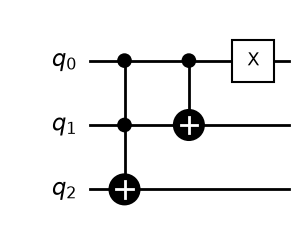

S_c (from the circuit, N = 8) =
[[0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0]]

Unitary: True
Reproduces 2I - S - S^dag: True
m = 2:  matches |(j+1) mod N> -> True
m = 3:  matches |(j+1) mod N> -> True
m = 4:  matches |(j+1) mod N> -> True
m = 5:  matches |(j+1) mod N> -> True


In [26]:
m = int(np.log2(N))                      # follow whatever N was set above
S_qc = cyclic_shift_circuit(m, power=+1)
save_circuit(S_qc, 'ModularIncrementer')

S_matrix = np.real_if_close(Operator(S_qc).data)
print(f"S_c (from the circuit, N = {N}) =")
print(np.round(np.real(S_matrix)).astype(int))   # round, not truncate: MCX synthesis
                                                  # returns 1 - O(1e-15) for m >= 4
print("\nUnitary:", np.allclose(S_matrix.conj().T @ S_matrix, np.eye(N)))
print("Reproduces 2I - S - S^dag:",
      np.allclose(2*np.eye(N) - S_matrix - S_matrix.conj().T, A_per))

# the same cascade works for any m
for mk in [2, 3, 4, 5]:
    Nm = 2**mk
    S_exact = np.zeros((Nm, Nm))
    for j in range(Nm):
        S_exact[(j + 1) % Nm, j] = 1.0
    U = Operator(cyclic_shift_circuit(mk, +1)).data
    print(f"m = {mk}:  matches |(j+1) mod N> ->", np.allclose(U, S_exact, atol=1e-10))


### Route 2 — the structured encoding  *(supplementary to Book §14.9)*

Equation $\mathbf{A}_{\mathrm{per}}=2\mathbf{I}-\mathbf{S}_{\mathrm c}-\mathbf{S}_{\mathrm c}^{\dagger}$
is a genuine LCU with coefficients $\{2,-1,-1\}$, so the four familiar stages apply unchanged:

| stage | what it does here |
|---|---|
| **PREP** | two ancilla qubits load $\sqrt{\lvert c_k\rvert/\alpha}=(\sqrt{1/2},\,1/2,\,1/2,\,0)$ |
| **SIGNS** | the pattern $(+,-,-)$ is injected by $\mathbf{Z}$ on *each* ancilla qubit, since $\mathbf{Z}\otimes\mathbf{Z}=\mathrm{diag}(1,-1,-1,1)$ and the fourth amplitude is zero |
| **SELECT** | $\mathbf{S}_{\mathrm c}$ on ancilla $\lvert 01\rangle$, $\mathbf{S}_{\mathrm c}^{\dagger}$ on $\lvert 10\rangle$ applied as the incrementer cascade with the ancilla carried as extra controls; the $\lvert 00\rangle$ branch is the identity and costs nothing |
| **UNPREP** | $\mathrm{PREP}^{\dagger}$ |

The ancilla register is **two qubits for every $N$**, and the subnormalization is
$\alpha=\lvert 2\rvert+\lvert-1\rvert+\lvert-1\rvert=4$, which matches
$\lVert\mathbf{A}_{\mathrm{per}}\rVert_2=4$ *exactly* for every even $N$ — the encoding is tight at
every problem size. `Structured_LCU_Ax` builds this circuit; `circulant_tridiagonal` covers the
general periodic stencil $a\mathbf{I}+b\mathbf{S}_{\mathrm c}+\bar b\,\mathbf{S}_{\mathrm c}^{\dagger}$.


terms   = ['I', 'S_c', 'S_c^dag']
coeffs  = [ 2. -1. -1.]
ancilla = 2   system = 3
alpha   = 4.0   (Z gates on ancilla qubits [0, 1])


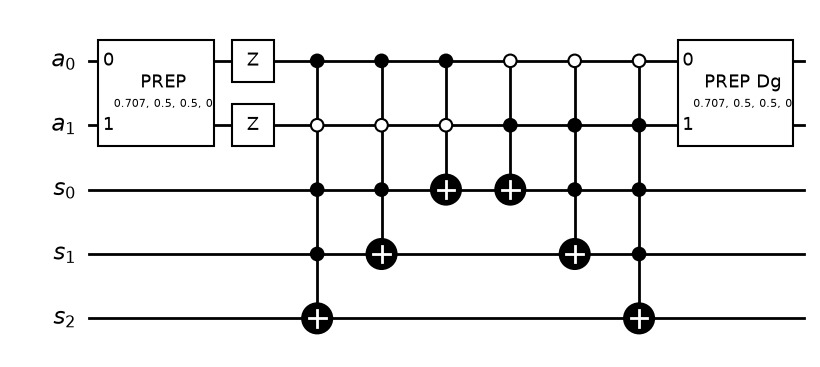


Recovered alpha * <0|U|0> :
[[ 2. -1.  0. -0.  0. -0.  0. -1.]
 [-1.  2. -1.  0.  0.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0. -0. -0.]
 [-0.  0. -1.  2. -1.  0.  0.  0.]
 [ 0. -0.  0. -1.  2. -1.  0. -0.]
 [ 0.  0.  0.  0. -1.  2. -1.  0.]
 [ 0.  0. -0. -0.  0. -1.  2. -1.]
 [-1.  0.  0.  0. -0.  0. -1.  2.]]

Verification of the structured block-encoding:
  block-encoding error   : 1.333e-14
  U unitary              : True
  alpha / ||A||_2        : 4.0000 / 4.0000 = 1.0000
  verdict                : PASS


In [27]:
qc_struct, md_struct = Structured_LCU_Ax(N)
print(f"terms   = {md_struct['terms']}")
print(f"coeffs  = {np.real_if_close(md_struct['coeffs'])}")
print(f"ancilla = {md_struct['num_ancilla']}   system = {md_struct['num_system']}")
print(f"alpha   = {md_struct['alpha']}   (Z gates on ancilla qubits {md_struct['sign_qubits']})")
save_circuit(qc_struct, 'ShiftEncoding')

U_struct, _ = Structured_Block_Encoding(N)
print("\nRecovered alpha * <0|U|0> :")
print(np.round(np.real_if_close(extract_encoded_block(U_struct, md_struct['num_ancilla'],
                                                     md_struct['alpha'])), 6))
print("\nVerification of the structured block-encoding:")
_ = verify_block_encoding(U_struct, A_per, md_struct['alpha'], md_struct['num_ancilla'])


### Applying both encodings to a state  *(supplementary to Book §14.9)*

Both circuits are drop-in replacements for one another: prepare $\lvert x\rangle$ on the system
register, run PREP–SELECT–UNPREP, post-select on ancilla $=\lvert 0\rangle$ (stride the statevector by
$2^{n_{\text{anc}}}$) and rescale by $\alpha$. The recovered vectors agree with the classical
$\mathbf{A}_{\mathrm{per}}x$ to machine precision.

The subnormalization is not just bookkeeping: the post-selection success probability is
$p_{\text{success}}=\lVert Ax\rVert^2/\alpha^2$, so a tighter $\alpha$ buys directly fewer repetitions.
At $N=8$ the Pauli route already carries $\alpha=5$ against the structured route's $\alpha=4$ — a
$(5/4)^2\approx1.6\times$ penalty in shots, growing with $N$.

In [28]:
N = 8
A8 = periodic_laplacian(N)

rng = np.random.default_rng(0)
x = rng.standard_normal(N)
x = x / np.linalg.norm(x)
expected = A8 @ x

results = {}
for name, (qc_, md_) in {
        'Pauli     ': LCU_Ax(A8, x, mode='statevector'),
        'structured': Structured_LCU_Ax(N, x=x)}.items():
    stride = md_['ancilla_zero_stride']
    block  = Statevector(qc_).data[::stride]
    alpha_ = np.real(md_['alpha'])
    results[name] = (np.real_if_close(block * alpha_), alpha_,
                     np.linalg.norm(block)**2)

print("classical A x :", np.round(expected, 4))
for name, (vec, alpha_, p) in results.items():
    print(f"{name}  :", np.round(vec, 4))
    print(f"{' '*12}   alpha = {alpha_:.3f},  p_success = {p:.4f}"
          f"  (||Ax||^2/alpha^2 = {np.linalg.norm(expected)**2/alpha_**2:.4f}),"
          f"  match = {np.allclose(vec, expected, atol=1e-8)}")

classical A x : [-0.3025 -0.5532  0.7023  0.0564 -0.8256 -0.0242  0.6976  0.2493]
Pauli       : [-0.3025 -0.5532  0.7023  0.0564 -0.8256 -0.0242  0.6976  0.2493]
               alpha = 5.000,  p_success = 0.0850  (||Ax||^2/alpha^2 = 0.0850),  match = True
structured  : [-0.3025 -0.5532  0.7023  0.0564 -0.8256 -0.0242  0.6976  0.2493]
               alpha = 4.000,  p_success = 0.1328  (||Ax||^2/alpha^2 = 0.1328),  match = True


### Dirichlet boundaries: the same circuit plus a flag  *(supplementary to Book §14.9)*

The matrix that actually arises from a 1D Poisson problem has *open* boundaries — it is
$\mathbf{A}_{\mathrm{per}}$ with the two wrap-around corner entries deleted. Rather than re-derive an
LCU, we reuse the periodic circuit and **flag** the wrapped contributions into a failure subspace.
After the shift has been applied, the wrapped component on the ancilla-$\lvert 01\rangle$ branch is the
one sitting on $\lvert 0\ldots0\rangle$, and on the ancilla-$\lvert 10\rangle$ branch the one sitting on
$\lvert 1\ldots1\rangle$ — so each check is a single multi-controlled $X$ onto one extra flag qubit.
Post-selecting on the flag being unset deletes exactly $\lvert 0\rangle\langle N{-}1\rvert$ and
$\lvert N{-}1\rangle\langle 0\rvert$.

The LCU is unchanged: still three terms, still $\alpha=4$. The ancilla count goes from two to three,
for every $N$. What $\alpha=4$ loses is tightness — $\|\mathbf{A}\|_2 = 2-2\cos(N\pi/(N+1))$, which is
$3.62$ at $N=4$ but climbs toward $4$ as the mesh is refined.

ancilla (2 LCU + 1 flag): 3   alpha: 4.0
alpha * <0|U|0> =
[[ 2. -1.  0. -0.]
 [-1.  2. -1.  0.]
 [ 0. -1.  2. -1.]
 [ 0.  0. -1.  2.]]
  block-encoding error   : 1.402e-14
  U unitary              : True
  alpha / ||A||_2        : 4.0000 / 3.6180 = 1.1056
  verdict                : PASS


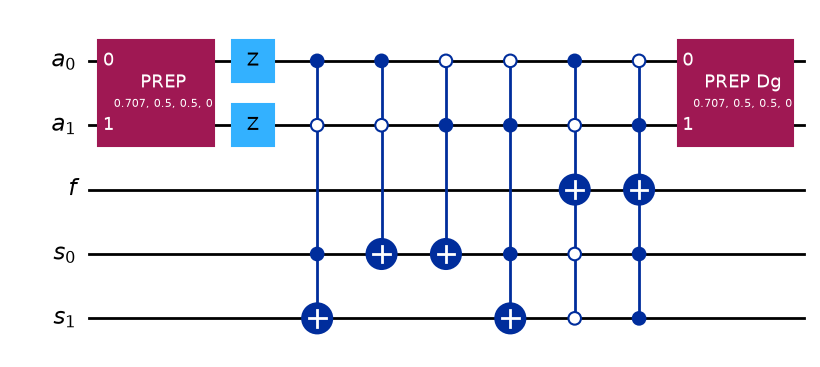


Tightness of alpha = 4 as the mesh is refined:
   N =   4   ||A||_2 = 3.6180   closed form = 3.6180   alpha/||A|| = 1.1056
   N =   8   ||A||_2 = 3.8794   closed form = 3.8794   alpha/||A|| = 1.0311
   N =  16   ||A||_2 = 3.9659   closed form = 3.9659   alpha/||A|| = 1.0086
   N =  32   ||A||_2 = 3.9909   closed form = 3.9909   alpha/||A|| = 1.0023
   N =  64   ||A||_2 = 3.9977   closed form = 3.9977   alpha/||A|| = 1.0006


In [29]:
from Chapter14_MatrixEncoding_functions import (dirichlet_laplacian, Dirichlet_LCU_Ax,
                                                 Dirichlet_Block_Encoding)

N = 4
A_dir = dirichlet_laplacian(N)
U_dir, md_dir = Dirichlet_Block_Encoding(N)
print(f"ancilla (2 LCU + 1 flag): {md_dir['num_ancilla']}   alpha: {md_dir['alpha']}")
print("alpha * <0|U|0> =")
print(np.round(np.real_if_close(
    extract_encoded_block(U_dir, md_dir['num_ancilla'], md_dir['alpha'])), 6))
_ = verify_block_encoding(U_dir, A_dir, md_dir['alpha'], md_dir['num_ancilla'])

qc_dir, _ = Dirichlet_LCU_Ax(N)
display(qc_dir.draw('mpl'))

print("\nTightness of alpha = 4 as the mesh is refined:")
for Nk in [4, 8, 16, 32, 64]:
    nrm = np.linalg.norm(dirichlet_laplacian(Nk), 2)
    print(f"   N = {Nk:3d}   ||A||_2 = {nrm:.4f}   "
          f"closed form = {2 - 2*np.cos(Nk*np.pi/(Nk+1)):.4f}   alpha/||A|| = {4/nrm:.4f}")

### How the two routes scale with $N$  *(supplementary to Book §14.9)*

This is the point of the example. For the periodic Laplacian the Pauli expansion has $3N/4$ terms and
$\alpha=\log_2 N+2$, while the exact norm stays pinned at $\lVert A\rVert_2=4$ — the encoding needs
more ancillas *and* gets looser as the mesh is refined. The shift decomposition never moves: three
terms, two ancilla qubits, $\alpha=4$.

The third panel is transpiled gate count, and it carries a caveat worth stating plainly: **it measures
a particular synthesis of the conditional shift, not the decomposition.** The $\mathcal{O}(\log N)$
figure quoted in the text assumes an ancilla-assisted synthesis of the multi-controlled $X$ gates;
Qiskit's default ancilla-free synthesis costs more than that bound. The final cell of this section
compares three ways of building the same SELECT stage.

In [30]:
rows = compare_periodic_encodings(N_list=(4, 8, 16, 32, 64))

      |          Pauli expansion           |        Shift decomposition        
    N |  terms  anc  alpha   depth      CX |  terms  anc  alpha   depth      CX
-------------------------------------------------------------------------------
    4 |      3    2   4.00      45      24 |      3    2   4.00      77      42
    8 |      6    3   5.00     304     172 |      3    2   4.00     198     114
   16 |     12    4   6.00    1584     860 |      3    2   4.00     451     270
   32 |     24    5   7.00    5607    3076 |      3    2   4.00     709     426
   64 |     48    6   8.00   17526    9804 |      3    2   4.00    1009     646


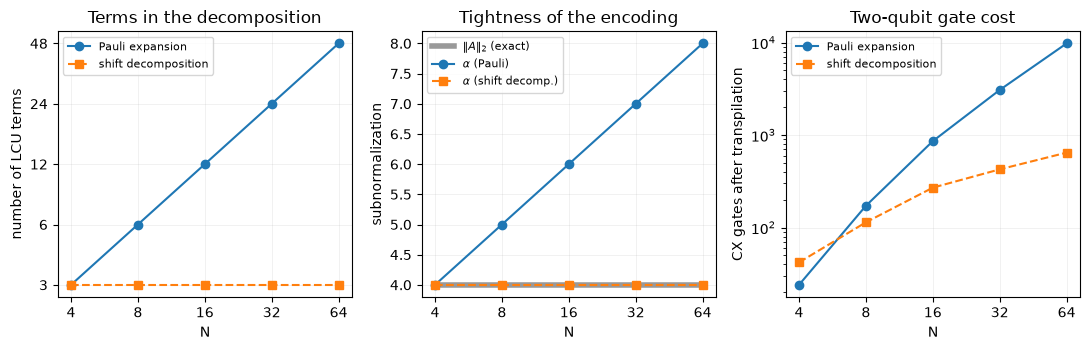

Fitted growth (last two sizes):
  Pauli terms   : 24 -> 48   (~ 3N/4)
  Pauli alpha   : 7 -> 8   (~ log2(N) + 2)
  Pauli CX      : 3076 -> 9804
  shift-decomp CX: 426 -> 646


In [31]:
fig, axes = plot_encoding_scaling(rows)
plt.show()

print("Fitted growth (last two sizes):")
r1, r2 = rows[-2], rows[-1]
print(f"  Pauli terms   : {r1['pauli_terms']} -> {r2['pauli_terms']}   (~ 3N/4)")
print(f"  Pauli alpha   : {r1['pauli_alpha']:.0f} -> {r2['pauli_alpha']:.0f}   (~ log2(N) + 2)")
print(f"  Pauli CX      : {r1['pauli_cx']} -> {r2['pauli_cx']}")
print(f"  shift-decomp CX: {r1['struct_cx']} -> {r2['struct_cx']}")

### The same machinery for a general periodic stencil  *(supplementary to Book §14.9)*

Nothing above used the particular values $(2,-1)$. Any periodic tridiagonal stencil
$A=a\mathbf{I}+b\mathbf{S}_{\mathrm c}+\bar b\,\mathbf{S}_{\mathrm c}^{\dagger}$ — an advection–diffusion
operator, a ring of springs with a complex phase — is the same three-term LCU with
$\alpha=\lvert a\rvert+2\lvert b\rvert$. When the coefficient phases are no longer a $\pm1$ pattern the
two $\mathbf{Z}$ gates are replaced automatically by a diagonal gate on the ancilla; everything else is
unchanged. Note that $\alpha$ is tight only when the extreme eigenvalue actually saturates the triangle
inequality, which is why the Laplacian case is special.

In [32]:
for (a_, b_) in [(2.0, -1.0), (3.0, -1.0), (2.0, -1 + 0.5j)]:
    Ng = 8
    Ag = circulant_tridiagonal(Ng, a=a_, b=b_)
    Ug, mdg = Structured_Block_Encoding(Ng, a=a_, b=b_)
    print(f"a = {a_}, b = {b_}   Hermitian: {np.allclose(Ag, Ag.conj().T)}, "
          f"sign gates: {mdg['sign_qubits']}")
    _ = verify_block_encoding(Ug, Ag, mdg['alpha'], mdg['num_ancilla'])
    print()

a = 2.0, b = -1.0   Hermitian: True, sign gates: [0, 1]
  block-encoding error   : 1.333e-14
  U unitary              : True
  alpha / ||A||_2        : 4.0000 / 4.0000 = 1.0000
  verdict                : PASS

a = 3.0, b = -1.0   Hermitian: True, sign gates: [0, 1]
  block-encoding error   : 2.134e-14
  U unitary              : True
  alpha / ||A||_2        : 5.0000 / 5.0000 = 1.0000
  verdict                : PASS

a = 2.0, b = (-1+0.5j)   Hermitian: True, sign gates: None
  block-encoding error   : 1.401e-14
  U unitary              : True
  alpha / ||A||_2        : 4.2361 / 4.1213 = 1.0278
  verdict                : PASS



### Three ways to build the same SELECT  *(supplementary to Book §14.9)*

The decomposition into three terms is what makes the encoding *possible*; the synthesis of the
**conditional** shift is what makes it cheap, and they are independent choices. All three circuits
below encode $\mathbf{A}_{\mathrm{per}}$ exactly at $\alpha=4$ and differ only in how SELECT applies
the shift:

1. **distributed control** — what the library does, and what the text describes: the control is
   pushed onto each gate of the incrementer cascade;
2. **wrapped control** — the same logic written as `cyclic_shift_circuit(m).control(2)`, i.e. one
   controlled gate around the whole cascade;
3. **phase gradient** — the Fourier form
   $\mathbf{S}_{\mathrm c}^{\pm1}=\mathrm{QFT}^{\dagger}\mathrm{diag}(e^{\pm2\pi ik/N})\mathrm{QFT}$,
   where the two transforms are common to both shift terms and cancel on the identity branch, so only
   the $m$ phases between them carry ancilla controls.

This material is not part of the printed chapter.

In [33]:
from qiskit import QuantumRegister
from qiskit.circuit.library import StatePreparation, QFTGate

COEFFS = np.array([2.0, -1.0, -1.0])

def _shell(N):
    """PREP + signs + (SELECT goes here) + UNPREP; returns circuit and registers."""
    m = int(np.log2(N))
    qr_a = QuantumRegister(2, 'a'); qr_s = QuantumRegister(m, 's')
    qc = QuantumCircuit(qr_a, qr_s)
    prep = np.pad(np.sqrt(np.abs(COEFFS) / 4.0), (0, 1))
    qc.append(StatePreparation(prep, label='PREP'), qr_a)
    qc.z(qr_a[0]); qc.z(qr_a[1])
    return qc, qr_a, qr_s, m

def _close(qc, qr_a):
    prep = np.pad(np.sqrt(np.abs(COEFFS) / 4.0), (0, 1))
    qc.append(StatePreparation(prep, label='PREP').inverse(), qr_a)
    return qc

def select_wrapped(N):
    qc, qr_a, qr_s, m = _shell(N)
    for i, power in [(1, +1), (2, -1)]:
        g = cyclic_shift_circuit(m, power=power).to_gate().control(2, ctrl_state=i)
        qc.append(g, [*qr_a, *qr_s])
    return _close(qc, qr_a)

def select_phase_gradient(N):
    qc, qr_a, qr_s, m = _shell(N)
    qc.append(QFTGate(m), qr_s)
    for t in range(m):
        ang = 2 * np.pi * (2 ** t) / N
        for i, power in [(1, +1), (2, -1)]:
            qc.append(PhaseGate(power * ang).control(2, ctrl_state=i), [*qr_a, qr_s[t]])
    qc.append(QFTGate(m).inverse(), qr_s)
    return _close(qc, qr_a)

from qiskit.circuit.library.standard_gates import PhaseGate

print(f"{'N':>5} {'distributed':>12} {'wrapped':>9} {'gradient':>9} {'Pauli':>8}   all exact?")
for Nk in [4, 8, 16, 32, 64]:
    circs = {'distributed': Structured_LCU_Ax(Nk)[0],
             'wrapped':     select_wrapped(Nk),
             'gradient':    select_phase_gradient(Nk)}
    exact = all(np.max(np.abs(extract_encoded_block(Operator(c).data, 2, 4.0)
                              - periodic_laplacian(Nk))) < 1e-9 for c in circs.values())
    cx = {k: encoding_resources(c)['cx'] for k, c in circs.items()}
    xk = np.zeros(Nk); xk[0] = 1.0
    cxp = encoding_resources(LCU_Ax(periodic_laplacian(Nk), xk)[0])['cx']
    print(f"{Nk:>5} {cx['distributed']:>12} {cx['wrapped']:>9} {cx['gradient']:>9} "
          f"{cxp:>8}   {exact}")

    N  distributed   wrapped  gradient    Pauli   all exact?
    4           42        42        36       24   True
    8          114       316        56      172   True
   16          270       902        86      860   True
   32          426      2742       114     3076   True
   64          646      6512       152     9804   True
